# Análise de Qualidade de Lucro: O lucro contábil está virando Caixa ?

## Vou usar o setor de Construção

### Lucro contábil ≠ Caixa

![Python](https://img.shields.io/badge/Python-3.10+-blue)
![Pandas](https://img.shields.io/badge/Pandas-2.0+-green)
![Status](https://img.shields.io/badge/Status-Concluído-brightgreen)

A construção civil funciona assim:

- a empresa fecha a venda;
- Contaliza ela na DRE(Regime de Competência);
- Porém, só há entrada de caixa quando a construção acabar.

*Usei as empresas: Curry, Cyrela e Even.*

Perguntas:

1. As contrutoras analisadas convertem lucro em caixa operacional?
2. Quais empresas apresentam accruals elevados?
3. Houve deterioração ou melhora na qualidade do Lucro?
4. Qual empresa tem o lucro mais "real" e qual tem o mais "contábil"?



> **Insight**: a Cury tem a melhor qualidade e a mais estável. Converte cerca de 70% do lucro em caixa.


> **Insight**: a Cyrela reporta lucro crescente, mas o **FCO** foi negativo em 2023 e 2025. O accruals ratio subiu de 9,6% para 11,6%.


> **Insight**: Já a Even saiu de uma situação crítica em 2024 (FCO negativos e accruals elevado) para um patamar mais saudável.

| Empresa | Perfil | Qualidade do lucro |
|---|---|---|
| Cury | Baixa renda, alto volume | **Boa e estável** |
| Even | Média renda, turnaround | **Melhorando** |
| Cyrela | Média-alta renda, nacional | **Ruim e piorando** |


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("dark_background")

In [56]:
df = pd.read_excel(r"C:\Users\ailto\OneDrive\Desktop\portifólio\lucroXcaixa\CURY.xlsx")


df

,Empresa,Ano,LL,FCO,ativo_total,PL,ativo_medio,FCO_LL,accruals,accruals_ratio,GCPL
0,CURY,2023,495611,455902,3092023,996980,NaN,0.919879,39709,NaN,0.457283
1,CURY,2024,698812,479564,4339295,1309539,3715659.0,0.686256,219248,0.059006,0.366208
2,CURY,2025,1081220,747046,5654395,1662054,4996845.0,0.690929,334174,0.066877,0.449472
3,Cyrela,2023,1105700,-615686,17371200,8499826,NaN,-0.556829,1721386,NaN,-0.072435
4,Cyrela,2024,1921052,63449,21240962,9949274,19306081.0,0.033028,1857603,0.096219,0.006377
5,Cyrela,2025,2395052,-358387,26109817,11466784,2367589.0,-0.149636,2753439,1.162972,-0.031254
6,Even,2024,121119,-182027,5178914,2069012,NaN,-1.502877,303146,NaN,-0.087978
7,Even,2025,299052,88842,5215835,2194756,2131884.0,0.297079,210210,0.098603,0.040479


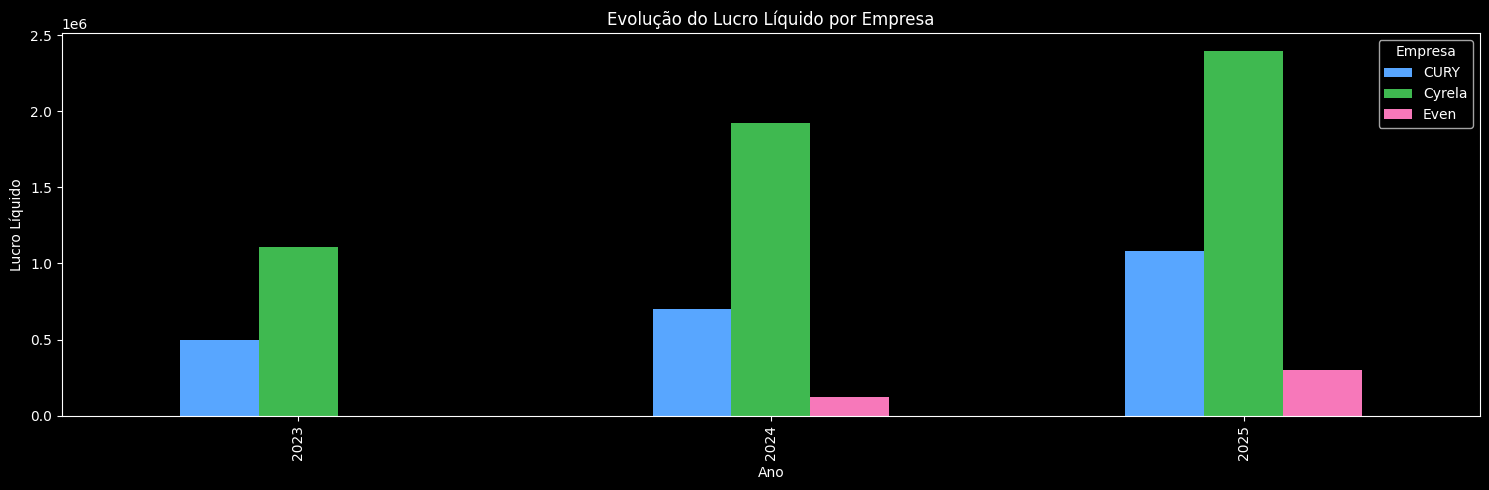

In [57]:
pivot = df.pivot(index="Ano", columns="Empresa", values="LL")

fig, ax = plt.subplots(figsize=(15,5))
    
pivot.plot(kind="bar", ax=ax, color=["#58a6ff", "#3fb950", "#f778ba"])

ax.set_title("Evolução do Lucro Líquido por Empresa")
ax.set_xlabel("Ano")
ax.set_ylabel("Lucro Líquido")
ax.legend(title="Empresa")
plt.tight_layout()
plt.show()

### Cyrela tem um crescimento de Lucro Líquido forte nos 3 anos

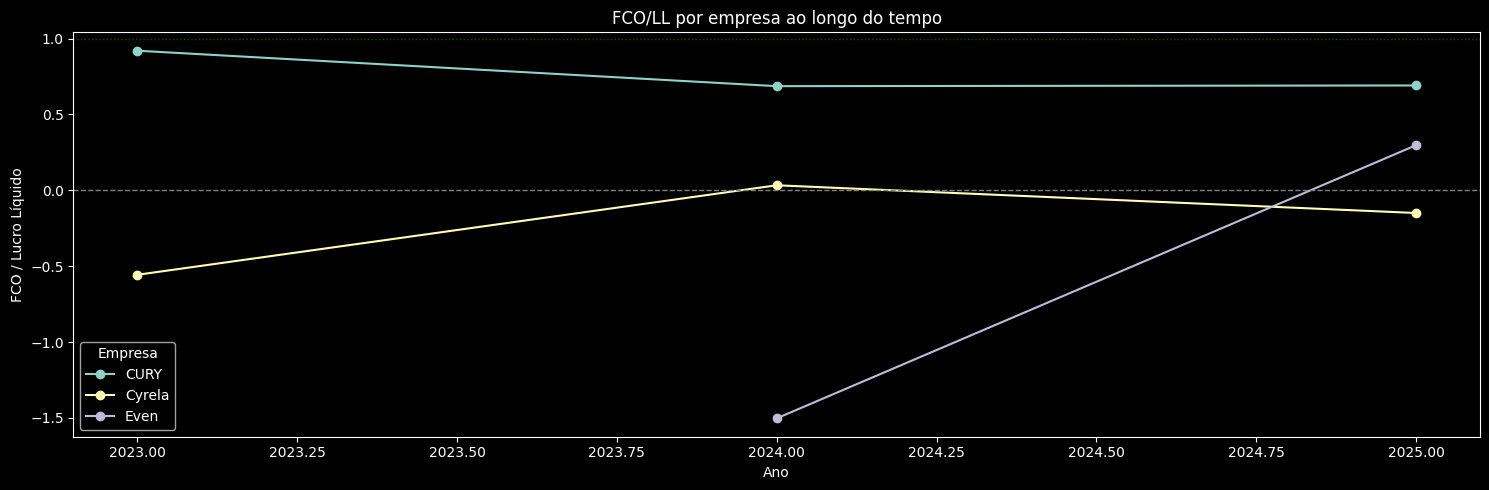

In [61]:
pivot = df.pivot(index="Ano", columns="Empresa", values="FCO_LL")

fig, ax =  plt.subplots(figsize=(15,5))
pivot.plot(kind="line", marker="o", ax=ax)

ax.set_title("FCO/LL por empresa ao longo do tempo")
ax.set_ylabel("FCO / Lucro Líquido")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axhline(1, color="green", linestyle=":", linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()

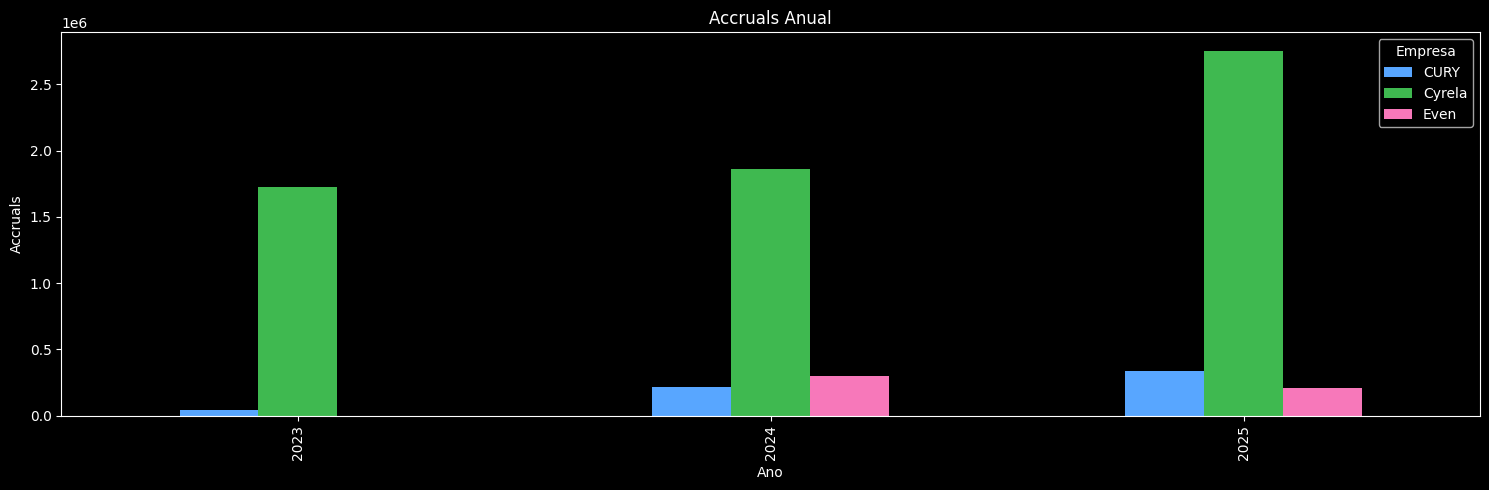

In [58]:
pivot = df.pivot(index="Ano", columns="Empresa", values="accruals")

fig, ax = plt.subplots(figsize=(15,5))
pivot.plot(kind="bar", ax=ax,
           color=["#58a6ff", "#3fb950", "#f778ba"])

ax.set_title("Accruals Anual")
ax.set_xlabel("Ano")
ax.set_ylabel("Accruals")
ax.legend(title="Empresa")
plt.tight_layout()
plt.show()

### Porém, tem o accruals crescente.

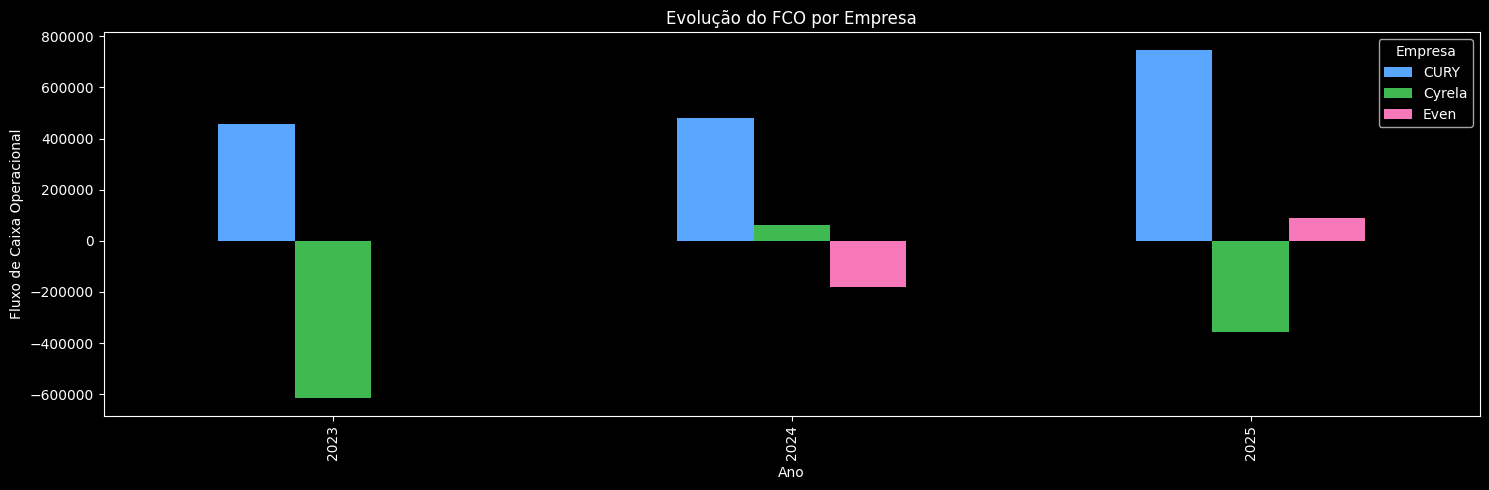

In [43]:
pivot = df.pivot(index="Ano", columns="Empresa", values="FCO")

fig, ax = plt.subplots(figsize=(15,5))
    
pivot.plot(kind="bar", ax=ax, color=["#58a6ff", "#3fb950", "#f778ba"])

ax.set_title("Evolução do FCO por Empresa")
ax.set_xlabel("Ano")
ax.set_ylabel("Fluxo de Caixa Operacional")
ax.legend(title="Empresa")
plt.tight_layout()
plt.show()

### A maior consequência é o Fluxo de Caixa Operacional está negativo

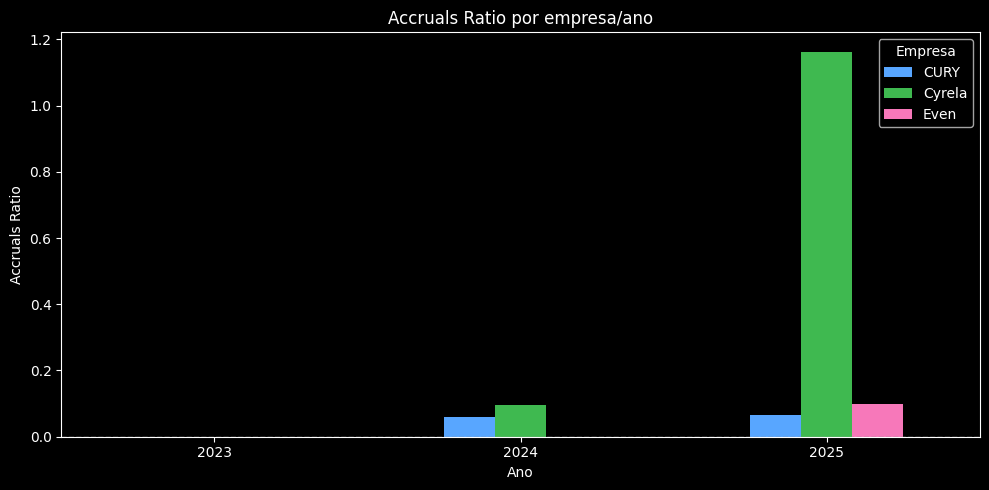

In [60]:
pivot = df.pivot(index="Ano", columns="Empresa", values="accruals_ratio")

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, color=["#58a6ff", "#3fb950", "#f778ba"])
ax.set_title("Accruals Ratio por empresa/ano")
ax.set_ylabel("Accruals Ratio")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

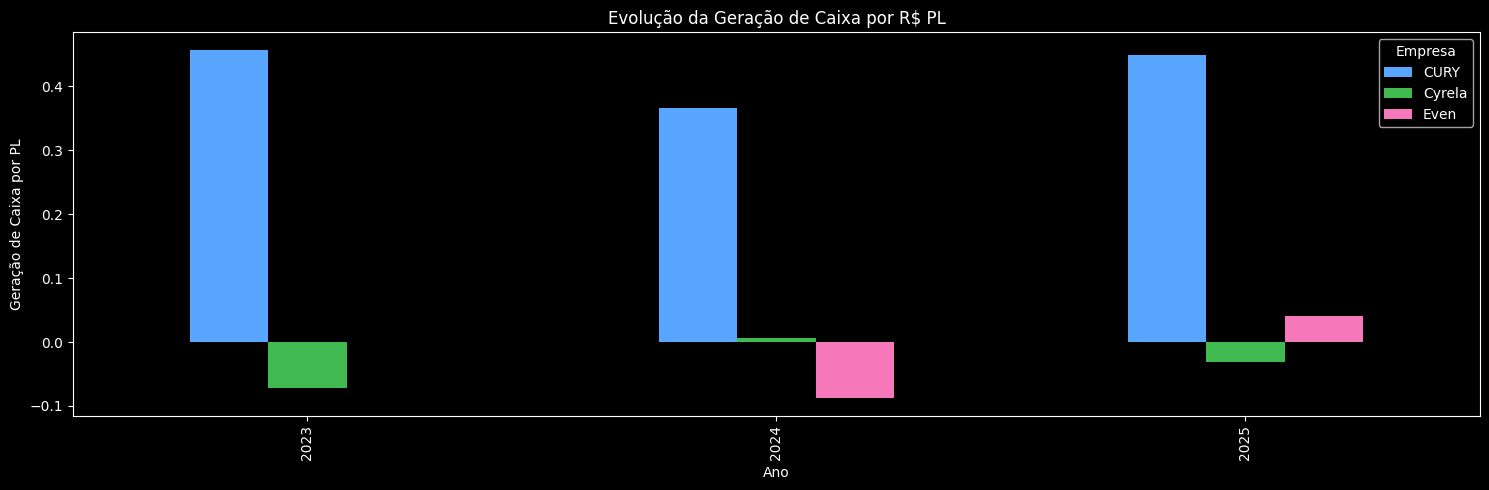

In [44]:
pivot = df.pivot(index="Ano", columns="Empresa", values="GCPL")

fig, ax = plt.subplots(figsize=(15,5))
    
pivot.plot(kind="bar", ax=ax, color=["#58a6ff", "#3fb950", "#f778ba"])

ax.set_title("Evolução da Geração de Caixa por R$ PL")
ax.set_xlabel("Ano")
ax.set_ylabel("Geração de Caixa por PL")
ax.legend(title="Empresa")
plt.tight_layout()
plt.show()

### Em contraste, a evolução da geração de caixa por patrimônio líquido da **Cury** se manteve forte nos 3 anos

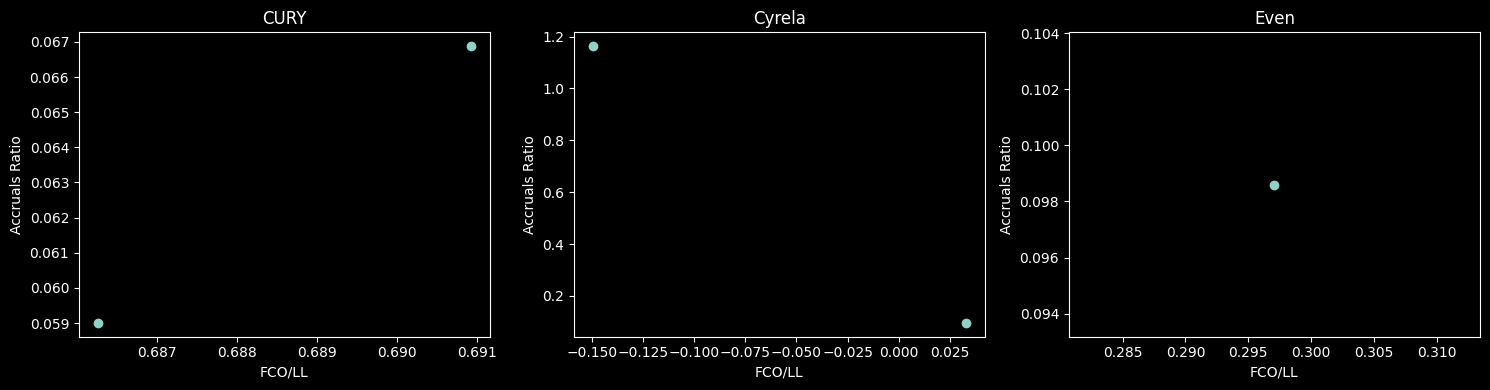

In [49]:
empresas = df["Empresa"].unique()

fig, axes = plt.subplots(1, len(empresas), figsize=(5 * len(empresas), 4))

for ax, empresa in zip(axes, empresas):
    dados = df[df["Empresa"] == empresa]
    ax.scatter(dados["FCO_LL"], dados["accruais_ratio"])
    ax.set_title(empresa)
    ax.set_xlabel("FCO/LL")
    ax.set_ylabel("Accruals Ratio")

plt.tight_layout()
plt.show()

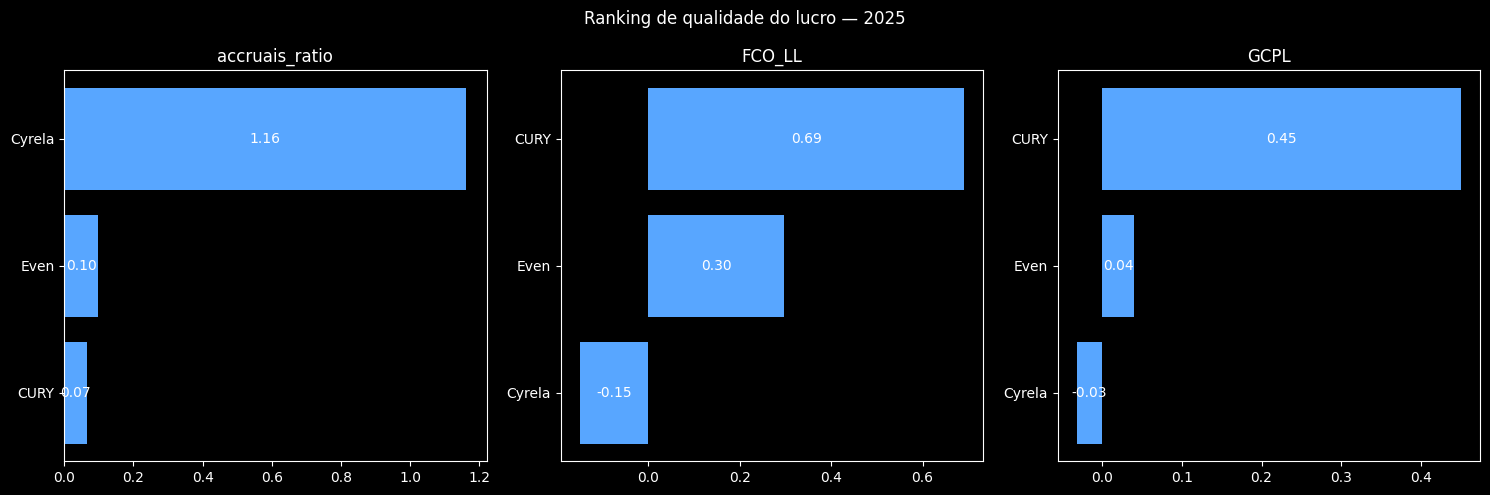

In [ ]:
rank = df[df["Ano"] == 2025].set_index("Empresa")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ["accruais_ratio", "FCO_LL", "GCPL"]):
    dados = rank[col].sort_values()
    ax.barh(dados.index, dados.values, color="#58a6ff")
    ax.set_title(col)
    ax.bar_label(ax.containers[0], label_type="center", fmt="%.2f")

plt.suptitle("Ranking de qualidade do lucro — 2025")
plt.tight_layout()
plt.show()